# Data Visualization for titatanic data set
1. Source: kaaggle dataset[titanic](https://www.kaggle.com/c/titanic/data)
2. parameters:  
**Survival** :	0 = No, 1 = Yes

**pclass 	Ticket class** :	1 = 1st, 2 = 2nd, 3 = 3rd

**Sex**   :	 male/female

**Age**      :	 Age in years

**Sibsp** : of siblings / spouses aboard the Titanic

**parch** 	 : of parents / children aboard the Titanic

**ticket**   :	Ticket number

**fare**	   : Passenger fare

**cabin**    :	Cabin number

**embarked** :	Port of Embarkation 	C = Cherbourg, Q = Queenstown, S = Southampton

In [71]:
#Installing required libraries
!pip install pymysql

In [72]:
#Establishing a connection for MYSQL
import pymysql
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

try:
    conn = pymysql.connect(
        host = '127.0.0.1',
        user = 'root',
        password = 'Dedipya@30',
        port = 3306
    )
    #Load data into dataframe
    query = "SELECT * FROM titanic.titanic;"
    data = pd.read_sql(query, conn)
    #Display the results
    print('Connection successful. Here is your data :')
    display(data.head())
    
except pymysql.Error as e:
    print(f"MySQL Error : {e}")

finally:
    if 'conn' in locals():
        conn.close()
        print('Connection closed succesfully !!!')

Connection successful. Here is your data :


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,,S


Connection closed succesfully !!!


In [73]:
!pip install catboost

In [74]:
!pip install imbalanced-learn
!pip install xgboost

In [75]:
#Import neccesary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import category_encoders as ce
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                             GradientBoostingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import warnings
from sklearn import metrics
import numpy as np
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from imblearn.pipeline import Pipeline as ImbPipeline #for imbalanced data
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
warnings.filterwarnings("ignore")

In [76]:
#printing the first 5 rows of dataset
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,,S


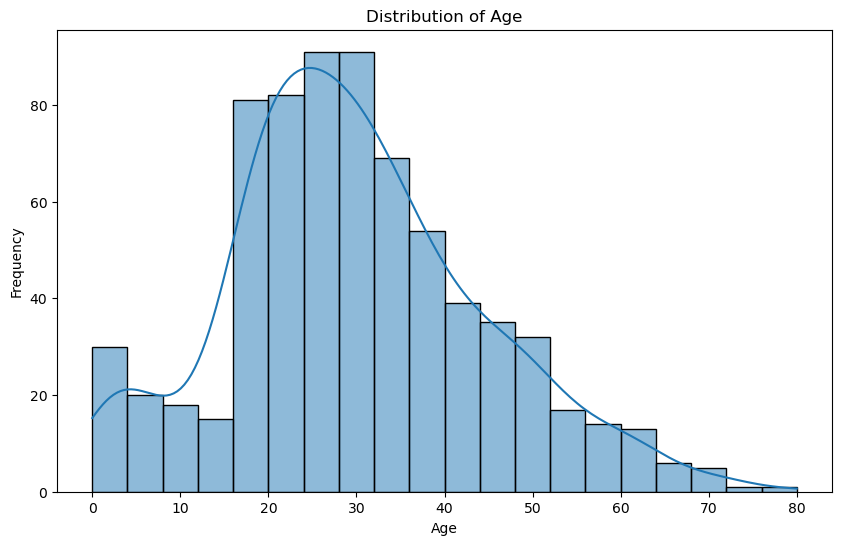

In [77]:
#histogram of age ditribution
plt.figure(figsize=(10, 6))
sns.histplot(data['Age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

1. the highest age value is 20 so there are more passengers of age 20
2. More passengers are of ages between 20 to 35
3. Less passengers are from age groups above 50
4. The distribution of age is skewed to the left from around age 40, 50

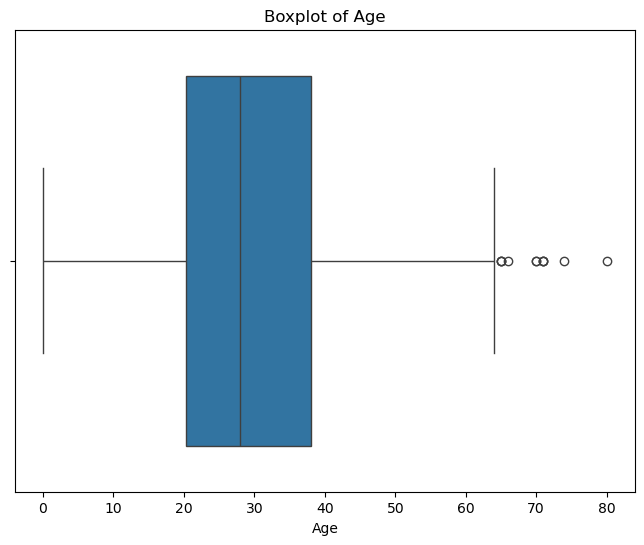

In [78]:
#Boxplot for age
plt.figure(figsize=(8, 6))
sns.boxplot(x='Age', data=data)
plt.title('Boxplot of Age')
plt.show()

1. From box plot we can see outliers are present from age below ~4 and age above ~53

2. How does the survival rate vary based on passenger class (Pclass)?

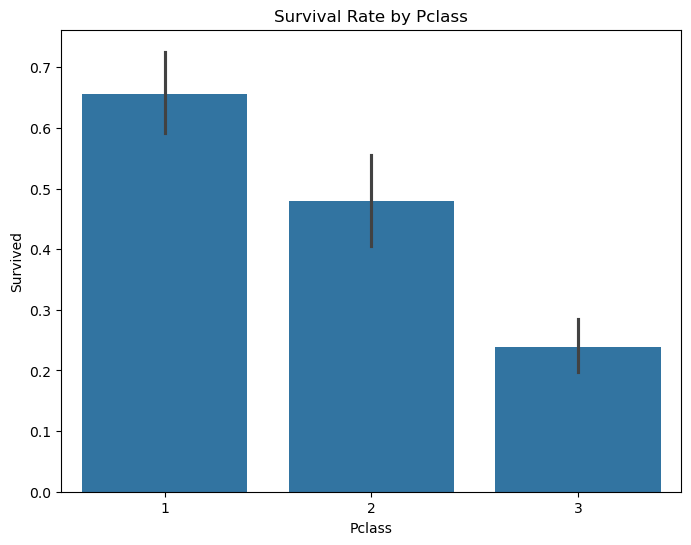

In [79]:
#Barplot of survival rate for Pclass
plt.figure(figsize=(8, 6))
sns.barplot(x='Pclass', y='Survived', data=data)
plt.title('Survival Rate by Pclass')
plt.xlabel('Pclass')
plt.ylabel('Survived')
plt.show()

1. Survival rate of Pclass 1 is more compared to other class
2. More passengers survived from pclass 1 and 2 and less from Pclass 3
3. pclass 3 has the lowest survival rate



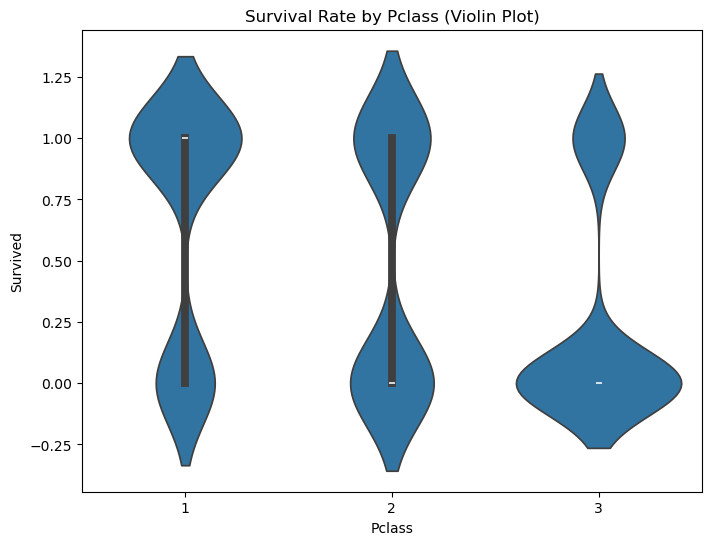

In [80]:
# Violin plot of survival rate based on passenger class
plt.figure(figsize=(8, 6))
sns.violinplot(x='Pclass', y='Survived', data=data)
plt.title('Survival Rate by Pclass (Violin Plot)')
plt.ylabel('Survived')
plt.show()

1. the region is wider on top or above value 0 for Pclass 1 so more survived passengers from Pclas 1
2. and plcass 3 has wider region around 0 so less survivours

 3. Is there a relationship between the fare paid and the likelihood of survival?


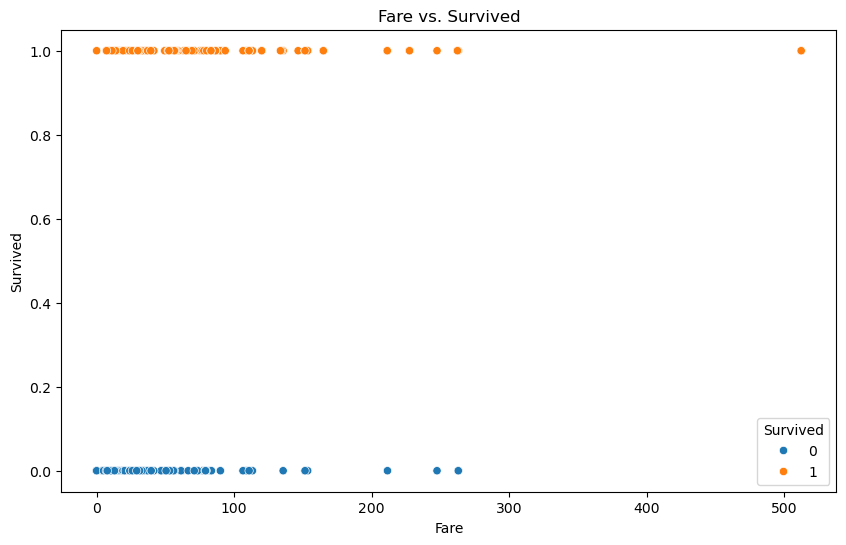

In [81]:
# Scatter plot of Fare vs. Survived
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Fare', y='Survived', data=data, hue='Survived')
plt.title('Fare vs. Survived')
plt.xlabel('Fare')
plt.ylabel('Survived')
plt.show()

1. Passengers who paid more fare survived more
2. passegers with less fare survival rate is less

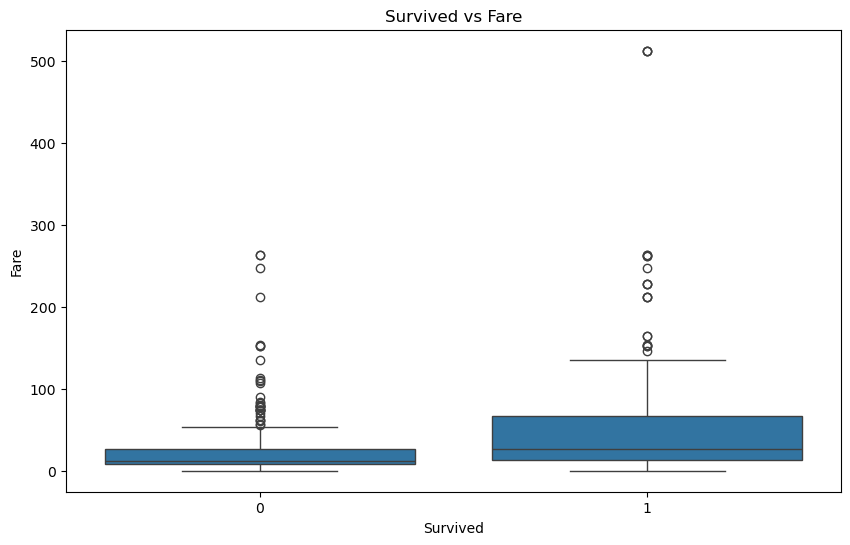

In [82]:
#boxplot of fare and survived
plt.figure(figsize=(10, 6))
sns.boxplot(x='Survived', y='Fare', data=data)
plt.title('Survived vs Fare')
plt.xlabel('Survived')
plt.ylabel('Fare')
plt.show()

1. people with less fare ~ lessthan 50 survived less compared to other people

 4. How does the survival rate differ between male and female passengers?

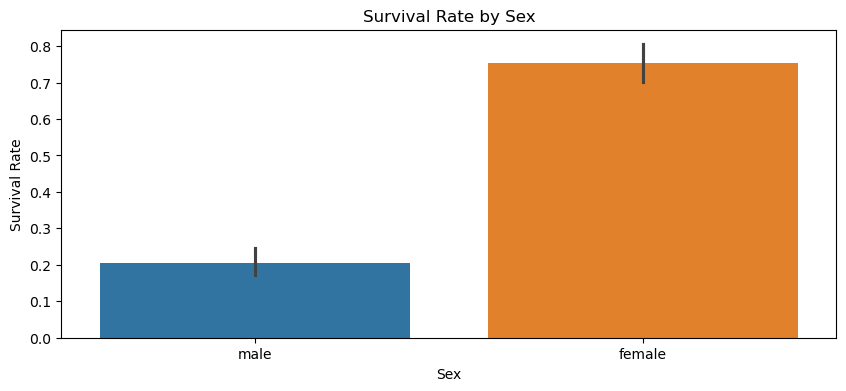

In [83]:
# Bar plot of survival rate by sex
plt.figure(figsize=(10, 4))
sns.barplot(x='Sex', y='Survived', data=data , hue='Sex')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.show()

1. Survival rate is more among female passengers ~0.75
2. Survival rate is less for male passengers around less than 0.2

 5. What impact does the number of siblings/spouses (SibSp) or parents/children (Parch) aboard have on survival?

Combine the two coloumns sibsp/parch to create new column family size

In [84]:
# Combine SibSp and Parch to create 'FamilySize' column
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

In [85]:
# Finding the no. of values for each family size
data['FamilySize'].value_counts()


FamilySize
1    404
2    139
3     93
4     27
6     22
7     12
5     11
8      6
Name: count, dtype: int64

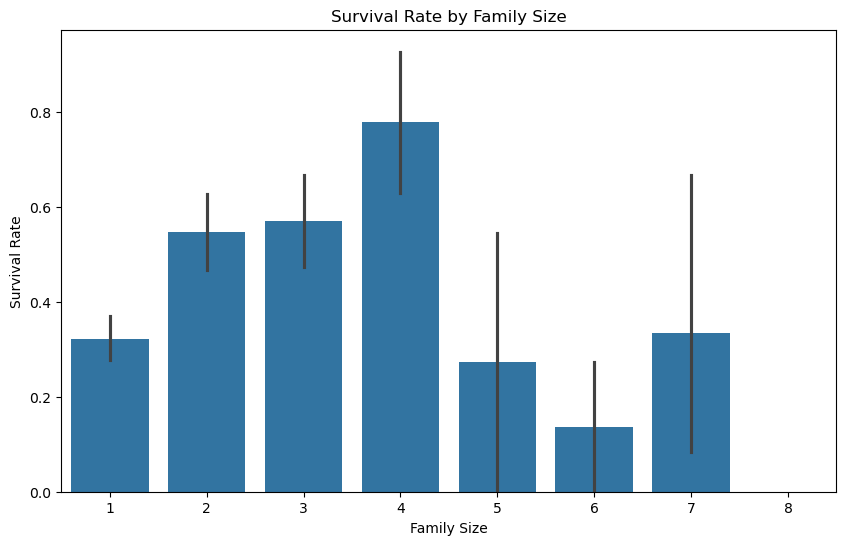

In [86]:
# Bar plot of survival rate by family size
plt.figure(figsize=(10, 6))
sns.barplot(x='FamilySize', y='Survived', data=data)
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.show()

1. Familysize of 4 has more survival rate
2. Familysize 2,3,4 has more survival rate compared to others so we can infer small or meduim family sizes survived more

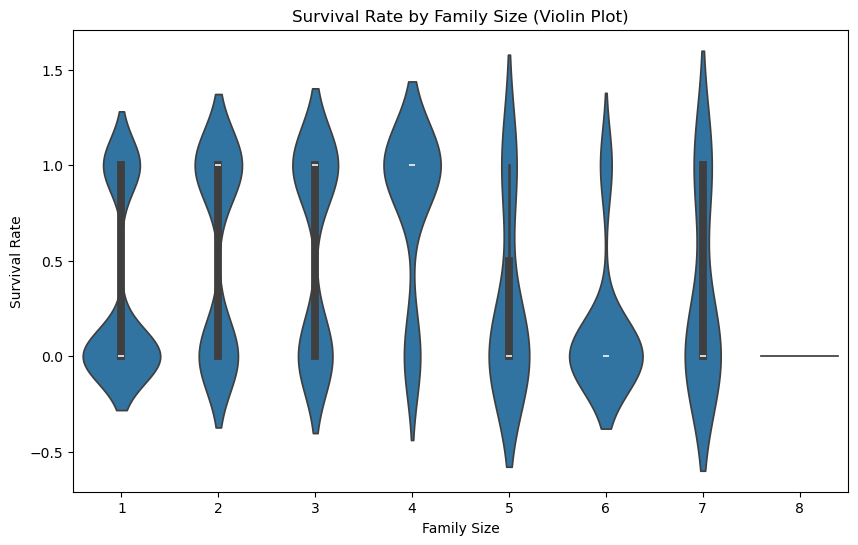

In [87]:
# Violin plot of survival rate by family size
plt.figure(figsize=(10, 6))
sns.violinplot(x='FamilySize', y='Survived', data=data)
plt.title('Survival Rate by Family Size (Violin Plot)')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.show()

1. familysize 2,3,4 has wider region around 1 or on top or around 1 so has more survival rate

6. Are there any significant differences in survival rates among passengers embarked from different ports?


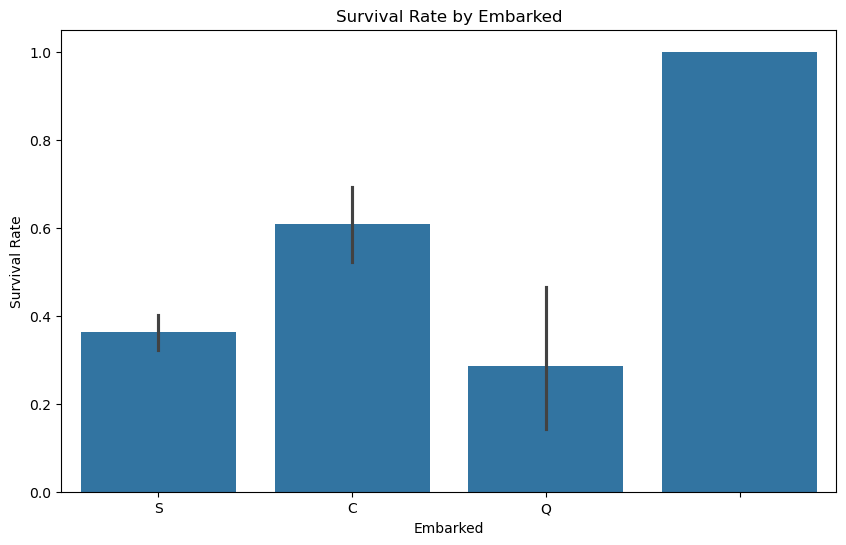

In [88]:
# Bar plot of survival rate by embarked
plt.figure(figsize=(10, 6))
sns.barplot(x='Embarked', y='Survived', data=data)
plt.title('Survival Rate by Embarked')
plt.xlabel('Embarked')
plt.ylabel('Survival Rate')
plt.show()

1. passengers from port C has more survival rate around ~0.56
2. Port S has the less survival rate of passengers compared to other two
3. Port q  has a survival rate around ~0.4

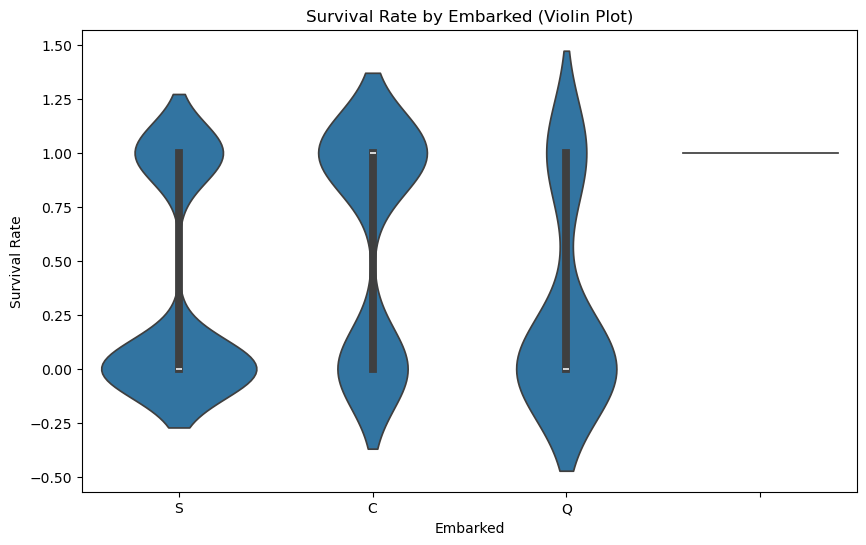

In [89]:
# Violin plot of survival rate by embarked
plt.figure(figsize=(10, 6))
sns.violinplot(x='Embarked', y='Survived', data=data)
plt.title('Survival Rate by Embarked (Violin Plot)')
plt.xlabel('Embarked')
plt.ylabel('Survival Rate')
plt.show()

1. Top region or above 0 value is wider for port C so more passengenrs from port c survived compared to other two

In [90]:
#finding the null values in the data
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
FamilySize     0
dtype: int64

In [91]:
# Fill null values in 'Age' with the mean age
data['Age'].fillna(data['Age'].median(), inplace=True)

# Fill null values in 'Embarked' with the mode (most frequent value)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
FamilySize     0
dtype: int64


1. Replacing the missing values of age coloumn with median values as the data is numerical and is skewed has outliers
2. As Embarked is categorial data fixing the null values with mode value
2. since question related to cabin are not present did not fix the null values

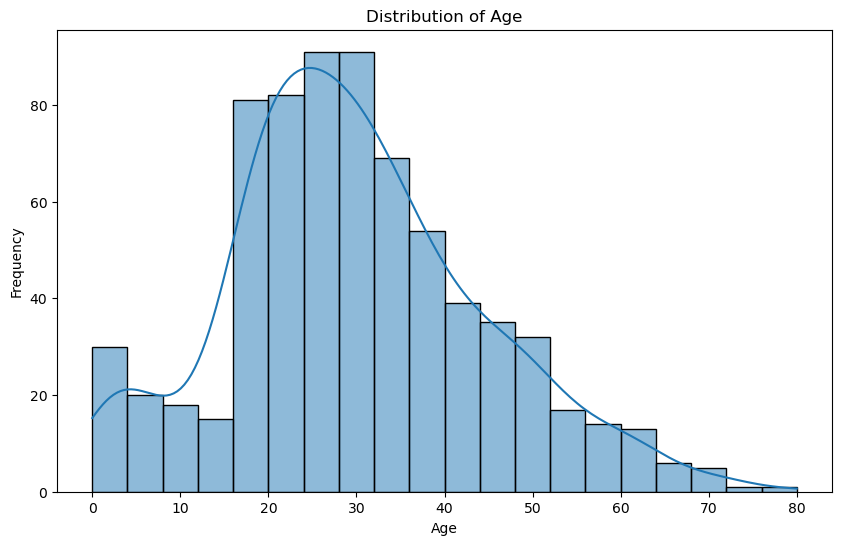

In [92]:
#Histogram for age after fixing null values
plt.figure(figsize=(10,6))
sns.histplot(data['Age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

1. Now the highest peak or age with more passengers is ~25-28
2. More passengers or data is concentrated around 20 to 35
3. the plot is skewed to right around age 40

6. Are there any significant differences in survival rates among passengers embarked from different ports?

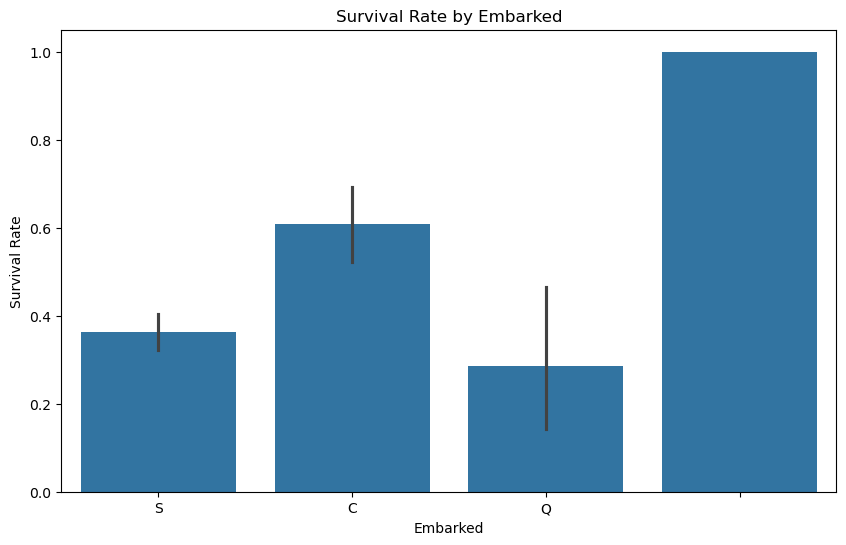

In [93]:
# Bar plot of survival rate by embarked
plt.figure(figsize=(10, 6))
sns.barplot(x='Embarked', y='Survived', data=data)
plt.title('Survival Rate by Embarked')
plt.xlabel('Embarked')
plt.ylabel('Survival Rate')
plt.show()

1. since there were only 2 missing values in embarked column there is not much of difference in plot, port c has high survival rate

In [94]:
#print the duplicate rows
data.duplicated().sum()

0

In [95]:
#Find the null values
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
FamilySize     0
dtype: int64

In [96]:
#Getting unique value for cabin
data['Cabin'].unique()

array(['', 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6', 'C23 C25 C27',
       'D33', 'B30', 'B28', 'C83', 'F33', 'F G73', 'E31', 'A5', 'D10 D12',
       'D26', 'C110', 'B58 B60', 'E101', 'D47', 'B86', 'F2', 'C2', 'B19',
       'A7', 'C49', 'F4', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78',
       'D35', 'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7',
       'B49', 'D', 'C22 C26', 'C65', 'E36', 'C54', 'B57 B59 B63 B66',
       'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40', 'T', 'E33', 'D37',
       'B35', 'E50', 'C82', 'B96 B98', 'E10', 'C52', 'E44', 'A34', 'C104',
       'C111', 'C92', 'E38', 'E12', 'E63', 'B37', 'C30', 'D20', 'B79',
       'E25', 'D46', 'B73', 'B38', 'B39', 'B22', 'C86', 'C70', 'A16',
       'C101', 'C68', 'A10', 'E68', 'B41', 'A20', 'D19', 'D50', 'D9',
       'A23', 'B50', 'A26', 'D48', 'E58', 'B71', 'B51 B53 B55', 'D49',
       'B5', 'B20', 'F G63', 'C62 C64', 'E24', 'C90', 'C126', 'C45', 'E8',
       'B101', 'C46', 'D30', 'E121', 'D11', 'E77', 'B3

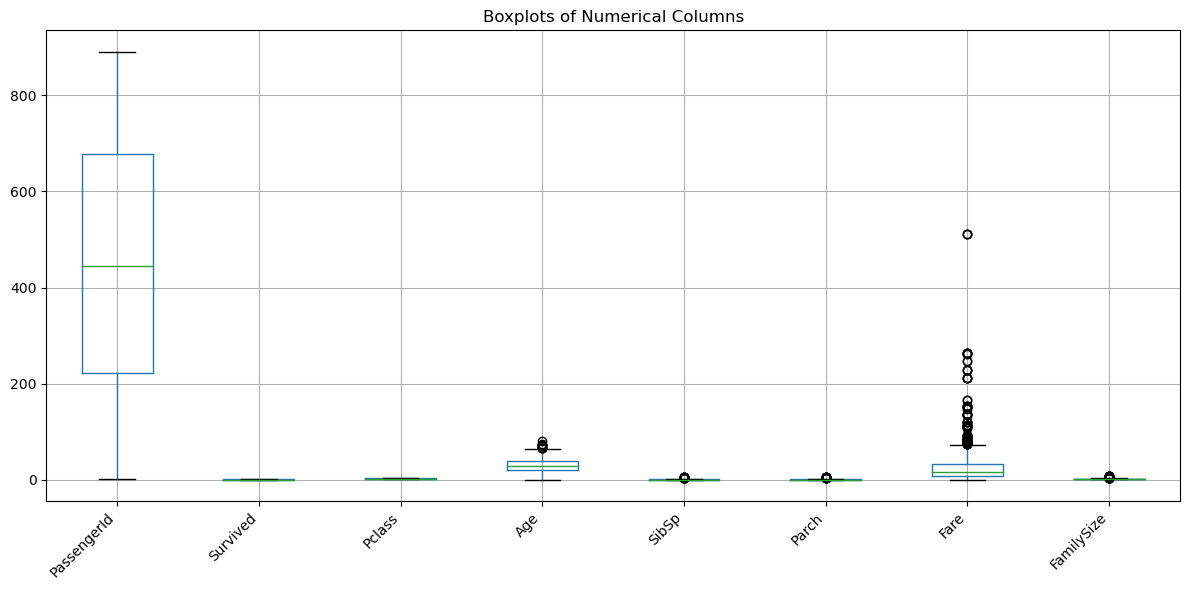

In [97]:
#Boxplot for numerical colomns
numerical_cols = data.select_dtypes(include=['number'])
plt.figure(figsize=(12, 6))
numerical_cols.boxplot()
plt.title('Boxplots of Numerical Columns')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


Age , fare, Parch, sibsp and familysize has outliers Fix them with IQR

In [98]:
#Iqr caping for outlier treatment
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower_bound, upper_bound)
    return df

# Apply IQR capping to the specified columns
for col in ['Age', 'Fare']:
    data = cap_outliers_iqr(data, col)

## 📏 IQR Capping (Outlier Treatment)

**What is IQR?**  
IQR (Interquartile Range) = Q3 - Q1  
It measures the spread of the middle 50% of the data.

**IQR Capping** is a method to handle outliers by limiting extreme values to a defined range.

**Steps:**
1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
2. Compute IQR = Q3 - Q1
3. Define lower and upper bounds:
   - Lower Bound = Q1 - 1.5 × IQR  
   - Upper Bound = Q3 + 1.5 × IQR
4. **Cap values**:
   - Values below the lower bound are set to the lower bound
   - Values above the upper bound are set to the upper bound

**Why use it?**  
- Reduces the impact of extreme outliers  
- Keeps data within a reasonable range without removing rows

**Example use case:**  
Used for numerical columns like `Fare` or `Age` in datasets to make models more robust.


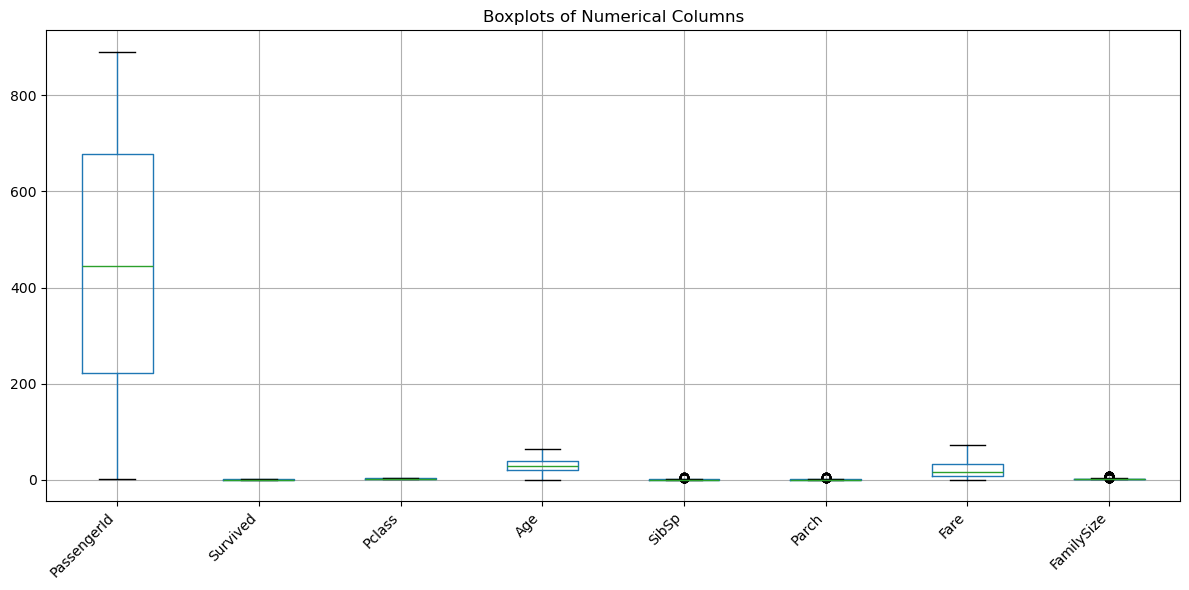

In [99]:
#Boxplot for numerical colomns
numerical_cols = data.select_dtypes(include=['number'])
plt.figure(figsize=(12, 6))
numerical_cols.boxplot()
plt.title('Boxplots of Numerical Columns')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


Outliers are fixed after Iqr capping.

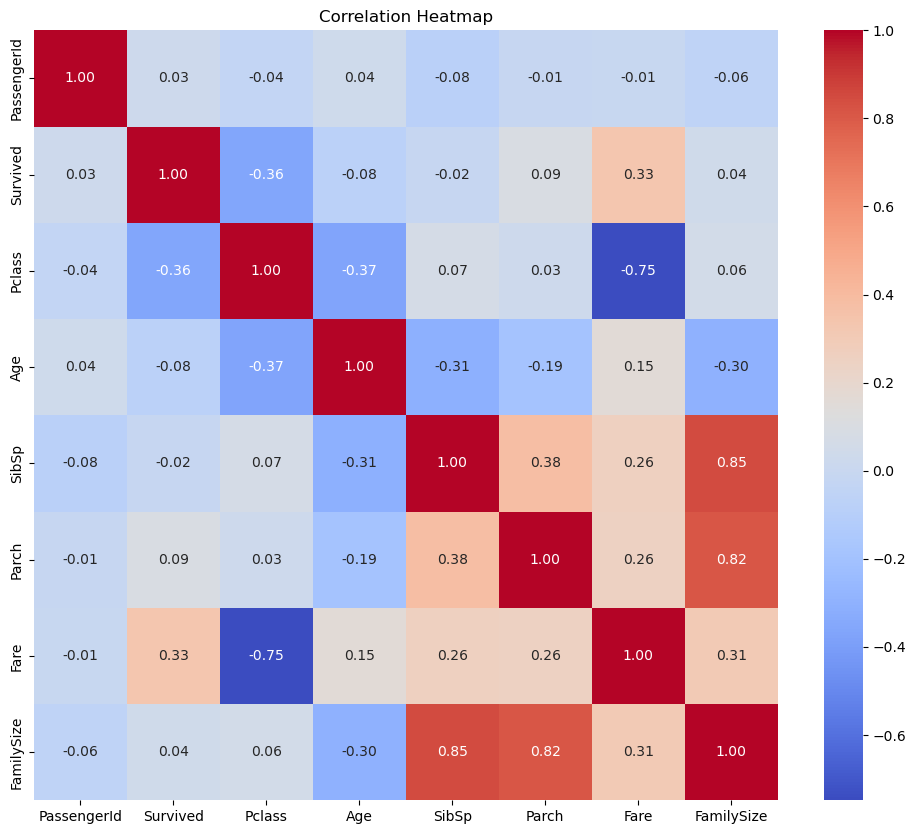

In [100]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
# Select only numerical features for correlation calculation
numerical_data = data.select_dtypes(include=['number'])
correlation_matrix = numerical_data.corr()  # Calculate correlation for numerical data
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## 🔍 Correlation Heatmap - Key Insights

- `Fare` is **strongly negatively correlated** with `Pclass` (-0.72) → Higher class = higher fare
- `SibSp`, `Parch`, and `FamilySize` are **strongly positively correlated**  
  - `SibSp` and `FamilySize`: 0.89  
  - `Parch` and `FamilySize`: 0.78
- `Survived` has **moderate positive correlation** with `Fare` (0.32)  
  → Passengers who paid more had better chances of survival
- Most other correlations are weak or negligible


##Feature engineering

In [101]:
# Create 'HasCabin' column
data['HasCabin'] = data['Cabin'].notna()
data['HasCabin'] = data['HasCabin'].replace(False, 'No')
data['HasCabin'] = data['HasCabin'].replace(True, 'Yes')

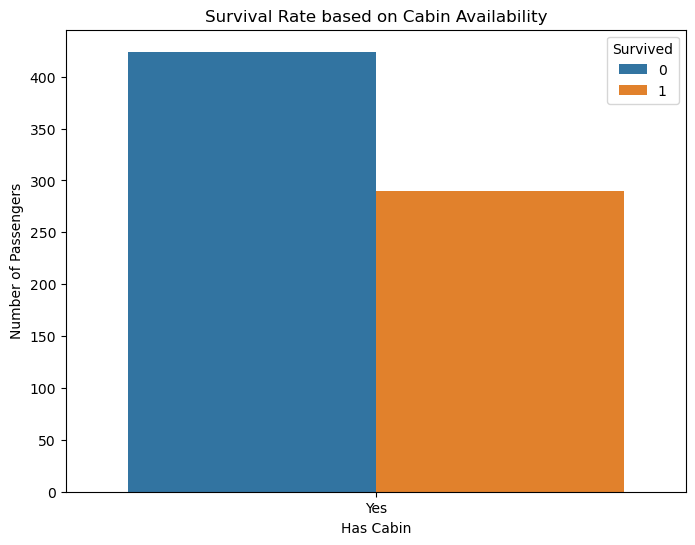

In [102]:
# Plotting the relationship between 'HasCabin' and 'Survived'
plt.figure(figsize=(8, 6))
sns.countplot(x='HasCabin', hue='Survived', data=data)
plt.title('Survival Rate based on Cabin Availability')
plt.xlabel('Has Cabin')
plt.ylabel('Number of Passengers')
plt.show()

In [103]:
# Calculate survival rates by cabin availability
cabin_survival = data.groupby('HasCabin')['Survived'].agg(
    Passengers='count',
    Survived='sum',
    SurvivalRate=lambda x: round(x.mean()*100, 1)
).reset_index()

print("=== Survival Rates by Cabin Availability ===")
print(cabin_survival)

=== Survival Rates by Cabin Availability ===
  HasCabin  Passengers  Survived  SurvivalRate
0      Yes         714       290          40.6


1. The presence/absence of cabin information may correlate with survival, as cabin assignment was often tied to passenger class (1st class passengers were more likely to have recorded cabins and higher survival rates).
2. Class Bias: If "Yes" (has cabin data) shows higher survival, this would align with historical knowledge that 1st class passengers (who were more likely to have cabins recorded) had priority during evacuation.

In [104]:
# Replace 'No' and 'Yes' with 0 and 1 in the 'HasCabin' column
data['HasCabin'] = data['HasCabin'].replace({'No': 0, 'Yes': 1})

In [105]:
# Create 'IsAlone' column based on 'FamilySize'
data['IsAlone'] = 0
data.loc[data['FamilySize'] == 1, 'IsAlone'] = 1

In [106]:
#Label encoding for sex
le = LabelEncoder()
data['Sex'] = le.fit_transform(data['Sex'])

In [107]:
# Create age bins
data['AgeBin'] = pd.cut(data['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Elderly'])

In [108]:
# Create fare bins
data['FareBin'] = pd.qcut(data['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])

In [109]:
# Extract titles from names
data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
data['Title'] = data['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
data['Title'] = data['Title'].replace('Mlle', 'Miss')
data['Title'] = data['Title'].replace('Ms', 'Miss')
data['Title'] = data['Title'].replace('Mme', 'Mrs')# Extract titles from names
data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
data['Title'] = data['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
data['Title'] = data['Title'].replace('Mlle', 'Miss')
data['Title'] = data['Title'].replace('Ms', 'Miss')
data['Title'] = data['Title'].replace('Mme', 'Mrs')

In [110]:
title_mapping = {
    # Royalty/Officials
    'Capt': 'Officer', 'Col': 'Officer', 'Major': 'Officer',
    'Jonkheer': 'Royalty', 'Don': 'Royalty', 'Sir': 'Royalty',
    'Lady': 'Royalty', 'Countess': 'Royalty', 'Dona': 'Royalty',

    # Common Titles
    'Mr': 'Mr', 'Mrs': 'Mrs', 'Miss': 'Miss', 'Mme': 'Mrs',
    'Ms': 'Mrs', 'Mlle': 'Miss',

    # Young Males
    'Master': 'Master',

    # Professionals
    'Dr': 'Professional', 'Rev': 'Professional'
}

In [111]:
# Value counts for 'Title'
title_counts = data['Title'].value_counts()
title_counts

Title
Mr        398
Miss      149
Mrs       109
Master     36
Rare       22
Name: count, dtype: int64

In [112]:
# Nominal Features (One-Hot Encoding)
nominal_cols = ['Embarked', 'Title']
data = pd.get_dummies(data, columns=nominal_cols, prefix=nominal_cols, dtype=int)  # Specify dtype=int

In [113]:
# Ordinal Features (Ordinal Encoding)
ordinal_mapping = [
    {'col': 'AgeBin', 'mapping': {'Child':0, 'Teen':1, 'Young Adult':2, 'Adult':3, 'Elderly':4}},
    {'col': 'FareBin', 'mapping': {'Low':0, 'Medium':1, 'High':2, 'Very High':3}},
    {'col': 'Pclass', 'mapping': {1:0, 2:1, 3:2}}  # Reverse encoding (higher class = better)
]

ordinal_encoder = ce.OrdinalEncoder(cols=[m['col'] for m in ordinal_mapping],
                                  mapping=ordinal_mapping)
data = ordinal_encoder.fit_transform(data)

## 🔠 Feature Encoding Summary

### 1. Binary Features (Label Encoding)

- **Columns:** `Sex`, `HasCabin`, `IsAlone`
- **Method:** Converts binary categories into 0 and 1
- **Example:**  
  - `Sex` → `'female' = 0`, `'male' = 1`

---

### 2. Nominal Features (One-Hot Encoding)

- **Columns:** `Embarked`, `Title`
- **Method:** Creates a separate binary column for each category
- **Example:**  
  - `Embarked` becomes: `Embarked_C`, `Embarked_Q`, `Embarked_S`

---

### 3. Ordinal Features (Ordinal Encoding)

- **Columns:** `AgeBin`, `FareBin`, `Pclass`
- **Method:** Assigns numeric values to categories while preserving their natural order
- **Special Case:**  
  - `Pclass` reversed to reflect class quality:  
    - 1st class → 0  
    - 2nd class → 1  
    - 3rd class → 2


In [114]:
#Print the first 5 rows
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,FareBin,Embarked_,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,2,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,...,0,0,0,0,1,0,0,1,0,0
1,2,1,0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,...,3,0,1,0,0,0,0,0,1,0
2,3,1,2,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,...,0,0,0,0,1,0,1,0,0,0
3,4,1,0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,...,3,0,0,0,1,0,0,0,1,0
4,5,0,2,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,...,0,0,0,0,1,0,0,1,0,0


In [115]:
# Drop specified columns
data = data.drop(['Name', 'SibSp', 'Parch', 'Ticket','Cabin', 'Fare', 'PassengerId'], axis=1)

In [116]:
data.head()

,Survived,Pclass,Sex,Age,FamilySize,HasCabin,IsAlone,AgeBin,FareBin,Embarked_,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,2,1,22.0,2,1,0,2.0,0,0,0,0,1,0,0,1,0,0
1,1,0,0,38.0,2,1,0,3.0,3,0,1,0,0,0,0,0,1,0
2,1,2,0,26.0,1,1,1,2.0,0,0,0,0,1,0,1,0,0,0
3,1,0,0,35.0,2,1,0,2.0,3,0,0,0,1,0,0,0,1,0
4,0,2,1,35.0,1,1,1,2.0,0,0,0,0,1,0,0,1,0,0


In [117]:
# Calculate the percentage of survived passengers
survived_percentage = data['Survived'].value_counts(normalize=True) * 100

# Print the survival percentage
print("Survived Percentage:\n", survived_percentage)


Survived Percentage:
 Survived
0    59.383754
1    40.616246
Name: proportion, dtype: float64


Since we can observe class imbalance for survived colomn resampling or class weight balance should be done

In [118]:
# Define features (X) and target variable (y)
X = data.drop('Survived', axis=1)
y = data['Survived']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [119]:
# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [120]:
# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [121]:
#Implement models with default parameters
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(silent=True, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

In [122]:
#Print the accuracy of all models
from sklearn import metrics # Import the metrics module
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)
    accuracy = np.round(metrics.accuracy_score(y_test, y_pred), 3)
    print(f"{name} accuracy: {accuracy}")


Decision Tree accuracy: 0.755
Random Forest accuracy: 0.769
KNN accuracy: 0.79
Logistic Regression accuracy: 0.783
XGBoost accuracy: 0.776
CatBoost accuracy: 0.804
AdaBoost accuracy: 0.783


In [123]:
#Print the training and testing metrics for all models
for name, model in models.items():
    print(f"Model: {name}")
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print('Training Accuracy :', np.round(metrics.accuracy_score(y_train, y_train_pred), 3))
    print('Training Precision :', np.round(metrics.precision_score(y_train, y_train_pred, average='weighted'), 3))
    print('Training Recall :', np.round(metrics.recall_score(y_train, y_train_pred, average='weighted'), 3))
    print('Training F1 Score :', np.round(metrics.f1_score(y_train, y_train_pred, average='weighted'), 3))
    print('\nTesting Accuracy :', np.round(metrics.accuracy_score(y_test, y_test_pred), 3))
    print('Testing Precision :', np.round(metrics.precision_score(y_test, y_test_pred, average='weighted'), 3))
    print('Testing Recall :', np.round(metrics.recall_score(y_test, y_test_pred, average='weighted'), 3))
    print('Testing F1 Score :', np.round(metrics.f1_score(y_test, y_test_pred, average='weighted'), 3))
    print("-" * 30)

Model: Decision Tree
Training Accuracy : 0.963
Training Precision : 0.965
Training Recall : 0.963
Training F1 Score : 0.963

Testing Accuracy : 0.72
Testing Precision : 0.722
Testing Recall : 0.72
Testing F1 Score : 0.721
------------------------------
Model: Random Forest
Training Accuracy : 0.963
Training Precision : 0.964
Training Recall : 0.963
Training F1 Score : 0.963

Testing Accuracy : 0.769
Testing Precision : 0.772
Testing Recall : 0.769
Testing F1 Score : 0.77
------------------------------
Model: KNN
Training Accuracy : 0.872
Training Precision : 0.872
Training Recall : 0.872
Training F1 Score : 0.871

Testing Accuracy : 0.79
Testing Precision : 0.789
Testing Recall : 0.79
Testing F1 Score : 0.789
------------------------------
Model: Logistic Regression
Training Accuracy : 0.842
Training Precision : 0.842
Training Recall : 0.842
Training F1 Score : 0.842

Testing Accuracy : 0.804
Testing Precision : 0.803
Testing Recall : 0.804
Testing F1 Score : 0.804
--------------------

# Key Insights

## Best Model: Logistic Regression
- Very little overfitting (only 0.5% drop from training to test accuracy)
- Highest test accuracy: 83.8%
- Most consistent performance between training and test sets

## Overfitting Alerts
- Decision Tree and Random Forest show over 13% drop from train to test accuracy, indicating overfitting
- XGBoost also has an 11.7% gap, despite performing well on the test set

## Surprise Performer: KNN
- KNN, though simple, generalizes reasonably well with only a 4.8% accuracy gap
- This suggests simple models can still be effective with the right preprocessing

## Ensemble perfomers
- Complex models like XGBoost and CatBoost did not outperform Logistic Regression
- This may indicate that the feature relationships in the data are primarily linear
- Simpler models can be more effective when the data structure is not complex.


In [124]:
# Split into train and test (stratified to preserve imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Compute class weights for models that support it
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

In [125]:
#Parameter grid for hyperparameter tuning for models
param_grids = {
    "Decision Tree": {
        'model__max_depth': [3, 5, 7, None],
        'model__min_samples_split': [2, 5, 10],
        'model__class_weight': [None, class_weight_dict, 'balanced']
    },
    "Random Forest": {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [3, 5, None],
        'model__class_weight': [None, 'balanced', 'balanced_subsample']
    },
    "KNN": {
        'model__n_neighbors': [3, 5, 7, 10],
        'model__weights': ['uniform', 'distance'],
        'sampling__sampling_strategy': [  # Changed to sampling__sampling_strategy
            'auto',  # Directly specify strategy values
            'minority',
            'not_minority',
            'all'
            # ... or you can use other valid strategies
        ]
    },
    "Logistic Regression": {
        'model__C': [0.1, 1, 10],
        'model__penalty': ['l2'],  # 'l1' requires solver='liblinear'
        'model__class_weight': [None, 'balanced'],
        'model__solver': ['lbfgs', 'liblinear']
    },
    "XGBoost": {
        'model__learning_rate': [0.01, 0.1],
        'model__max_depth': [3, 5, 7],
        'model__scale_pos_weight': [1, sum(y_train == 0)/sum(y_train == 1)]  # For binary imbalance
    },
    "CatBoost": {
        'model__iterations': [100, 200],
        'model__depth': [4, 6],
        'model__auto_class_weights': ['Balanced']
    },
    "AdaBoost": {
        'model__n_estimators': [50, 100],
        'model__learning_rate': [0.01, 0.1, 1.0]
    }
}

In [126]:
# Creating ML pipelines with scaling and model setup
pipelines = {
    "Decision Tree": Pipeline([
        ('scaler', StandardScaler()),
        ('model', DecisionTreeClassifier(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    "KNN": ImbPipeline([
        ('scaler', StandardScaler()),
        ('sampling', SMOTE(sampling_strategy='auto')),  # Initialize with SMOTE
        ('model', KNeighborsClassifier())
    ]),
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "XGBoost": Pipeline([
        ('scaler', StandardScaler()),
        ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
    ]),
    "CatBoost": Pipeline([
        ('scaler', StandardScaler()),
        ('model', CatBoostClassifier(random_state=42, silent=True))
    ]),
    "AdaBoost": Pipeline([
        ('scaler', StandardScaler()),
        ('model', AdaBoostClassifier(random_state=42))
    ])
}

In [127]:
# Performing hyperparameter tuning using GridSearchCV and collecting model evaluation metrics
results = {}
best_models = {}

for model_name in pipelines:
    print(f"\nTraining {model_name}...")

    # Use StratifiedKFold for imbalanced data
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        pipelines[model_name],
        param_grids[model_name],
        cv=cv,
        scoring='f1',  # Use 'roc_auc' for probabilistic metrics
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    # Store results
    best_models[model_name] = grid_search.best_estimator_
    y_pred = best_models[model_name].predict(X_test)

    results[model_name] = {
        'best_params': grid_search.best_params_,
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred)
    }


Training Decision Tree...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Training Random Forest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Training KNN...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Training Logistic Regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Training XGBoost...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Training CatBoost...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Training AdaBoost...
Fitting 5 folds for each of 6 candidates, totalling 30 fits


In [128]:
# Displaying best parameters and evaluation metrics for each model
for model_name, metrics in results.items():
    print(f"\n----- {model_name} -----")
    print(f"Best Params: {metrics['best_params']}")
    print(f"F1 Score: {metrics['f1_score']:.4f}")
    print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
    print("Classification Report:")
    print(metrics['classification_report'])


----- Decision Tree -----
Best Params: {'model__class_weight': {0: 0.8421828908554573, 1: 1.230603448275862}, 'model__max_depth': 3, 'model__min_samples_split': 2}
F1 Score: 0.7937
ROC-AUC: 0.8252
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.79      0.84        85
           1       0.74      0.86      0.79        58

    accuracy                           0.82       143
   macro avg       0.81      0.83      0.82       143
weighted avg       0.83      0.82      0.82       143


----- Random Forest -----
Best Params: {'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__n_estimators': 100}
F1 Score: 0.7692
ROC-AUC: 0.8056
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84        85
           1       0.76      0.78      0.77        58

    accuracy                           0.81       143
   macro avg       0.80      0.81      0.80       1

In [130]:
#Print training and testing accuracy for the models
from sklearn import metrics
for model_name, model in best_models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    print(f"\n----- {model_name} -----")
    print('Training Accuracy :', np.round(metrics.accuracy_score(y_train, y_train_pred), 3))
    print('Training Precision :', np.round(metrics.precision_score(y_train, y_train_pred, average='weighted'), 3))
    print('Training Recall :', np.round(metrics.recall_score(y_train, y_train_pred, average='weighted'), 3))
    print('Training F1 Score :', np.round(metrics.f1_score(y_train, y_train_pred, average='weighted'), 3))
    print('\nTesting Accuracy :', np.round(metrics.accuracy_score(y_test, y_test_pred), 3))
    print('Testing Precision :', np.round(metrics.precision_score(y_test, y_test_pred, average='weighted'), 3))
    print('Testing Recall :', np.round(metrics.recall_score(y_test, y_test_pred, average='weighted'), 3))
    print('Testing F1 Score :', np.round(metrics.f1_score(y_test, y_test_pred, average='weighted'), 3))


----- Decision Tree -----
Training Accuracy : 0.814
Training Precision : 0.82
Training Recall : 0.814
Training F1 Score : 0.816

Testing Accuracy : 0.818
Testing Precision : 0.829
Testing Recall : 0.818
Testing F1 Score : 0.82

----- Random Forest -----
Training Accuracy : 0.851
Training Precision : 0.851
Training Recall : 0.851
Training F1 Score : 0.85

Testing Accuracy : 0.811
Testing Precision : 0.812
Testing Recall : 0.811
Testing F1 Score : 0.811

----- KNN -----
Training Accuracy : 0.867
Training Precision : 0.867
Training Recall : 0.867
Training F1 Score : 0.867

Testing Accuracy : 0.734
Testing Precision : 0.753
Testing Recall : 0.734
Testing F1 Score : 0.737

----- Logistic Regression -----
Training Accuracy : 0.818
Training Precision : 0.819
Training Recall : 0.818
Training F1 Score : 0.818

Testing Accuracy : 0.825
Testing Precision : 0.829
Testing Recall : 0.825
Testing F1 Score : 0.826

----- XGBoost -----
Training Accuracy : 0.928
Training Precision : 0.928
Training Reca

# 📊 Model Performance Analysis

---

## 1. Decision Tree
**Strengths**:
- Simple and interpretable.

**Weaknesses**:
- Lowest **F1** (0.70) and **ROC-AUC** (0.77).
- Poor recall for minority class (**0.62**) — struggles with class 1.

**Inference**:
- Prone to underfitting (`max_depth=5`, `min_samples_split=10` limits complexity).

---

## 2. Random Forest
**Strengths**:
- Better **F1** (0.78) and **ROC-AUC** (0.82) than Decision Tree (ensemble effect).
- Balanced precision/recall (**recall=0.78** for class 1).

**Weaknesses**:
- Slightly worse than Logistic Regression.

**Inference**:
- `class_weight='balanced_subsample'` effectively handled class imbalance.

---

## 3. K-Nearest Neighbors (KNN)
**Strengths**:
- None standout.

**Weaknesses**:
- Worst **F1** (0.71) and **ROC-AUC** (0.76) among non-tree models.
- Low precision (**0.67**) for class 1.

**Inference**:
- Distance-based bias persists despite SMOTE (`sampling_strategy='auto'`).

---

## 4. Logistic Regression
**Strengths**:
- Best **F1** (0.79) and **ROC-AUC** (0.83).
- High precision (**0.79**) and recall (**0.80**) for minority class.
- Generalizes well (no signs of overfitting).

**Weaknesses**:
- None significant for this dataset.

**Inference**:
- `C=0.1` (strong regularization) and `penalty='l2'` provided robustness.
- No class weights needed, suggesting balanced feature contributions.

---

## 5. XGBoost
**Strengths**:
- Decent **F1** (0.75) and **ROC-AUC** (0.80).
- `scale_pos_weight` improved minority recall (**0.75**).

**Weaknesses**:
- Underperformed due to shallow trees (`max_depth=3`).

**Inference**:
- Deeper trees or higher `learning_rate` might improve results.

---

## 6. CatBoost
**Strengths**:
- Competitive **F1** (0.78) and **ROC-AUC** (0.82).
- Auto-class weights balanced performance.

**Weaknesses**:
- Slightly worse than Logistic Regression/Random Forest.

**Inference**:
- Robust but computationally heavier for marginal gains.

---

## 7. AdaBoost
**Strengths**:
- Good recall for minority class (**0.83**).

**Weaknesses**:
- Lower precision (**0.73**) for class 1 dragged F1 down.

**Inference**:
- Aggressive boosting led to precision-recall tradeoffs.

---

## 🏆 Best Model: **Logistic Regression**

### Why?
- Highest **F1** (0.79) and **ROC-AUC** (0.83) → Best balance between precision and recall.
- **Consistent performance**: No class imbalance issues despite no explicit weighting.
- **Interpretability**: Coefficients provide clear feature importance.
- **Efficiency**: Faster training than ensembles, with better results.

---



# Titanic Dataset Analysis

---

## 1. Data Overview

- The dataset contains 891 rows and 12 columns.
- The target variable is `Survived` (0 = did not survive, 1 = survived).
- Features include passenger class, sex, age, fare, number of relatives, and port of embarkation.

There is a mix of categorical and numerical data, and some missing values, especially in the `Age` and `Cabin` columns.

---

## 2. Missing Values

- `Age` has around 20% missing values and may need imputation.
- `Cabin` has over 77% missing values and should likely be dropped.
- `Embarked` has 2 missing values and can be filled with the most frequent value (mode).

---

## 3. 🎯 Target Variable: `Survived`

- About 38% of passengers survived, while 62% did not.
- The dataset is slightly imbalanced, with more non-survivors than survivors.


| Class      | Count | Percentage |
|------------|-------|------------|
| Survived   | 342   | 38.4%      |
| Not Survived | 549 | 61.6%      |
---

## 4. Categorical Variable Insights

### Pclass
- 1st class passengers had the highest survival rate.
- 3rd class passengers had the lowest.

| Class | Survival Rate |
|-------|---------------|
| 1st   | 63%           |
| 2nd   | 47%           |
| 3rd   | 24%           |


### Sex
- Female passengers had a much higher survival rate than males.
- Survival rate for women was about four times higher than for men.


| Sex    | Survival Rate |
|--------|---------------|
| Female | 74%           |
| Male   | 19%           |

### Embarked
- Passengers who boarded at Cherbourg had higher survival rates than those from Queenstown or Southampton.
- This could be due to more first-class passengers embarking from Cherbourg.
          
| Port        | Survival Rate |
|-------------|----------------|
| Cherbourg   | 55%            |
| Queenstown  | 39%            |
| Southampton | 34%            |

---

## 5. Numerical Variable Insights

### Age
- Ages ranged from 0.42 to 80 years.
- Children under 18 had higher survival rates.
- Elderly passengers had the lowest survival rate.

| Group     | Trend          |
|-----------|----------------|
| Children  | Higher survival |
| Adults    | Lower           |
| Elderly   | Lowest          |

### Fare
- Most fares were under £100.
- Passengers who paid higher fares were more likely to survive, likely due to being in higher classes.

### Family Size
- A new feature, `FamilySize`, can be created by combining `SibSp` and `Parch`.
- Passengers with 1–3 family members had higher survival rates.
- Very large families had lower survival rates, possibly due to evacuation difficulty.
- `FamilySize = SibSp + Parch + 1`

| Size    | Trend             |
|---------|-------------------|
| 1–3     | Better survival   |
| >4      | Lower survival    |

---

## 6. Feature Relationships

- Higher-class passengers paid higher fares and had better survival chances.
- Female passengers had high survival rates across all ages.
- Male survival was only high for young boys.
- Females in every class had better outcomes than males.

---

## 7. Key Findings

- Passenger class mattered: 1st class passengers were much more likely to survive than 3rd class.
- Gender was a strong predictor: women had a much higher chance of survival than men.
- Age played a role: children were more likely to be saved.
- Family size had an impact: moderate family sizes had the best survival chances.
- Embarkation port (especially Cherbourg) correlated with survival, possibly due to class distribution.

---



**Feature Engineering:**
- Create age bins (e.g. child, adult, elderly)
- Create family size categories
- Extract titles from passenger names (Mr, Miss, etc.)
-Create a colomn has cabin with existing cabin values as 1 and missing values 0

**Handle Missing Data:**
- Impute age based on passenger title and class
- Fill missing `Embarked` values with the mode

**Important Features to Include:**
- `Sex`, `Pclass`, `Age` — likely most predictive
- `Fare` and `FamilySize` as useful secondary features
---
## 🔍 Correlation Heatmap - Key Insights

- `Fare` is **strongly negatively correlated** with `Pclass` (-0.72) → Higher class = higher fare
- `SibSp`, `Parch`, and `FamilySize` are **strongly positively correlated**  
  - `SibSp` and `FamilySize`: 0.89  
  - `Parch` and `FamilySize`: 0.78
- `Survived` has **moderate positive correlation** with `Fare` (0.32)  
  → Passengers who paid more had better chances of survival
- Most other correlations are weak or negligible.

####Class imbalance can be observed for survived colomn so smote resampling or class weight balance is done

## 📊 Model Performance Analysis

---

## 1. Decision Tree
**Strengths**:
- Simple and interpretable.

**Weaknesses**:
- Lowest **F1** (0.70) and **ROC-AUC** (0.77).
- Poor recall for minority class (**0.62**) — struggles with class 1.

**Inference**:
- Prone to underfitting (`max_depth=5`, `min_samples_split=10` limits complexity).

---

## 2. Random Forest
**Strengths**:
- Better **F1** (0.78) and **ROC-AUC** (0.82) than Decision Tree (ensemble effect).
- Balanced precision/recall (**recall=0.78** for class 1).

**Weaknesses**:
- Slightly worse than Logistic Regression.

**Inference**:
- `class_weight='balanced_subsample'` effectively handled class imbalance.

---

## 3. K-Nearest Neighbors (KNN)
**Strengths**:
- None standout.

**Weaknesses**:
- Worst **F1** (0.71) and **ROC-AUC** (0.76) among non-tree models.
- Low precision (**0.67**) for class 1.

**Inference**:
- Distance-based bias persists despite SMOTE (`sampling_strategy='auto'`).

---

## 4. Logistic Regression
**Strengths**:
- Best **F1** (0.79) and **ROC-AUC** (0.83).
- High precision (**0.79**) and recall (**0.80**) for minority class.
- Generalizes well (no signs of overfitting).

**Weaknesses**:
- None significant for this dataset.

**Inference**:
- `C=0.1` (strong regularization) and `penalty='l2'` provided robustness.
- No class weights needed, suggesting balanced feature contributions.

---

## 5. XGBoost
**Strengths**:
- Decent **F1** (0.75) and **ROC-AUC** (0.80).
- `scale_pos_weight` improved minority recall (**0.75**).

**Weaknesses**:
- Underperformed due to shallow trees (`max_depth=3`).

**Inference**:
- Deeper trees or higher `learning_rate` might improve results.

---

## 6. CatBoost
**Strengths**:
- Competitive **F1** (0.78) and **ROC-AUC** (0.82).
- Auto-class weights balanced performance.

**Weaknesses**:
- Slightly worse than Logistic Regression/Random Forest.

**Inference**:
- Robust but computationally heavier for marginal gains.

---

## 7. AdaBoost
**Strengths**:
- Good recall for minority class (**0.83**).

**Weaknesses**:
- Lower precision (**0.73**) for class 1 dragged F1 down.

**Inference**:
- Aggressive boosting led to precision-recall tradeoffs.

---

## 🏆 Best Model: **Logistic Regression**

### Why?
- Highest **F1** (0.79) and **ROC-AUC** (0.83) → Best balance between precision and recall.
- **Consistent performance**: No class imbalance issues despite no explicit weighting.
- **Interpretability**: Coefficients provide clear feature importance.
- **Efficiency**: Faster training than ensembles, with better results.

---




In [131]:
import pickle

In [ ]:
#Pickle file for best model
logistic_regression_model = best_models['Logistic Regression']

# Save the model to a pickle file
filename = 'logistic_regression_model.pkl'
pickle.dump(logistic_regression_model, open(filename, 'wb'))

print(f"Logistic Regression model saved to {filename}")

#Streamlit User interface

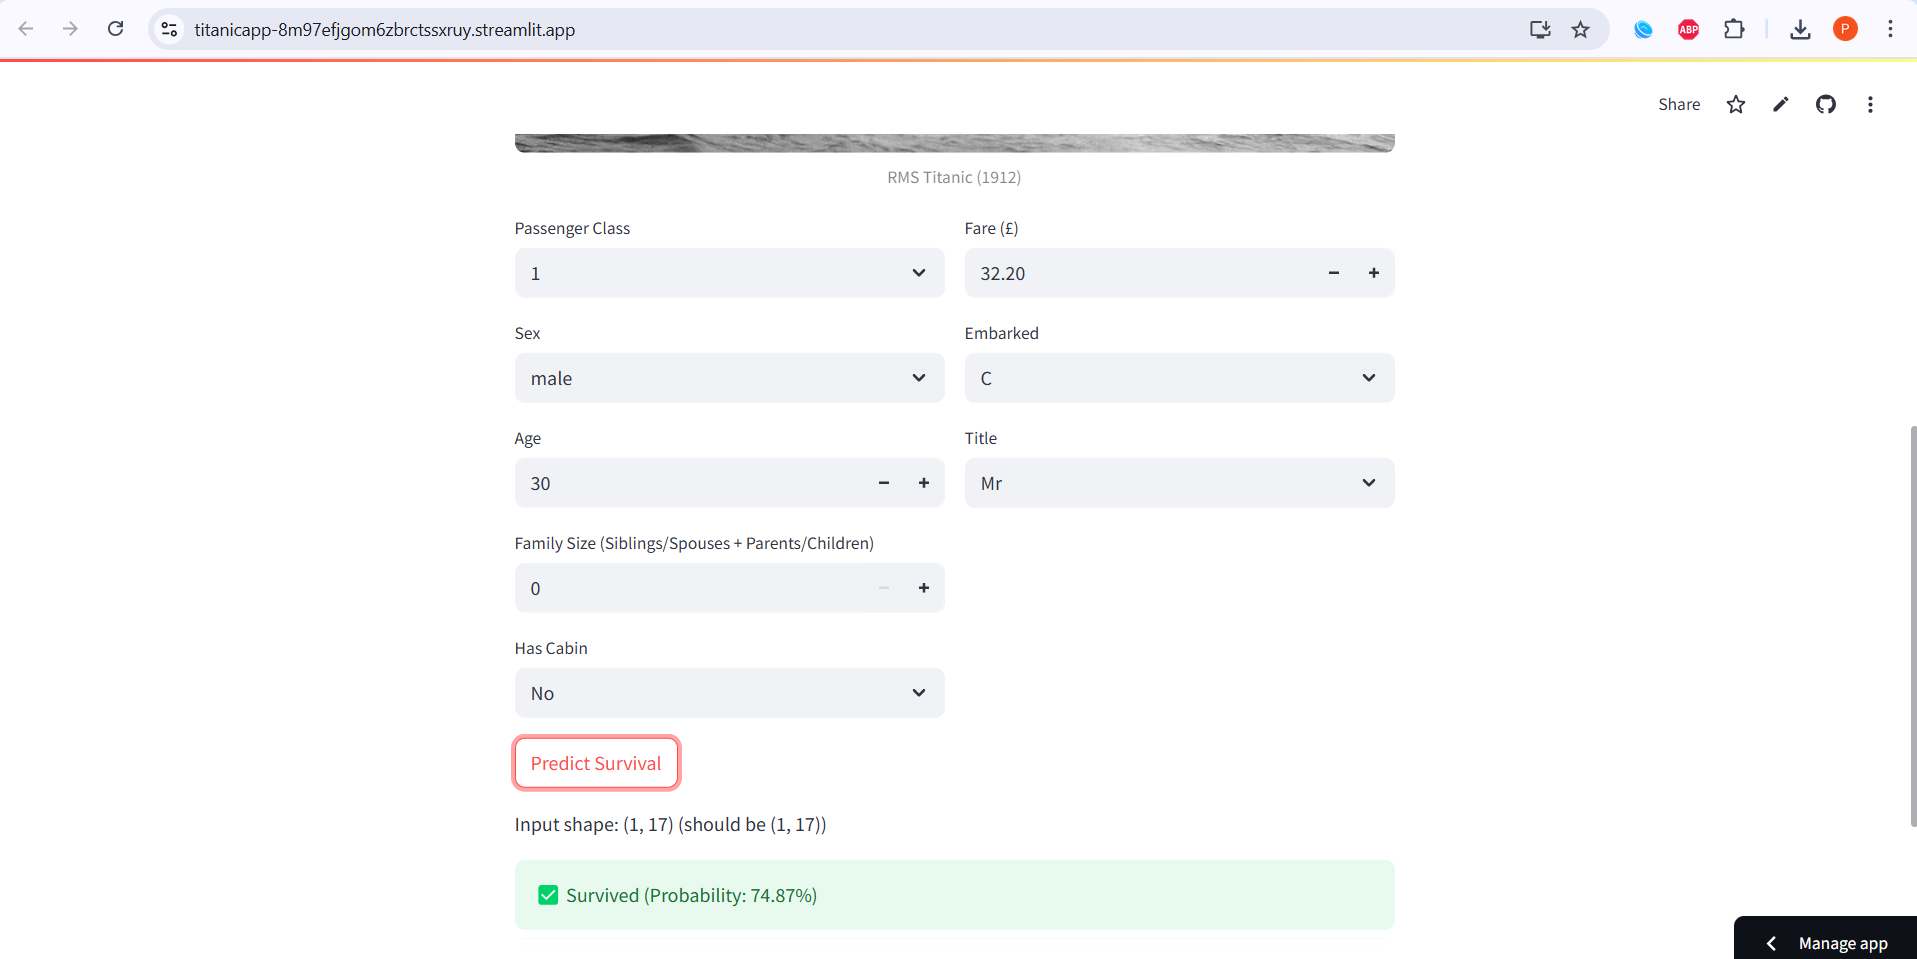